In [5]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

print("Data loaded successfully!")
print("Shape", df.shape)

Data loaded successfully!
Shape (541909, 8)


In [7]:
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (541909, 8)

Column Names:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [8]:
# Remove rows where customerID is missing

df = df.dropna(subset=["CustomerID"])

#Remove rows where Description is missing
df= df.dropna(subset=["Description"])

# Check the new shape and missing values
print("New Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

New Shape: (406829, 8)

Missing Values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [9]:
#Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

#Check negative quantity
print("Negative quantity:",(df["Quantity"]<0).sum())

#Check zero/negative price
print("Non-positive UnitPrice:",(df["UnitPrice"]<= 0).sum())

Duplicate rows: 5225
Negative quantity: 8905
Non-positive UnitPrice: 40


In [10]:
# Remove duplicate rows
df = df.drop_duplicates()

# Keep only positive quantities
df = df[df["Quantity"]>0]

# Keep only positive unit prices
df = df[df["UnitPrice"]>0]

print("Cleaned Shape:", df.shape)

print("\nNegative Quantity:",(df["Quantity"]<= 0).sum())
print("Non-positive UnitPrice:", (df["UnitPrice"]<= 0).sum())

Cleaned Shape: (392692, 8)

Negative Quantity: 0
Non-positive UnitPrice: 0


In [12]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df[["CustomerID", "Quantity", "UnitPrice", "TotalAmount"]].head()

,CustomerID,Quantity,UnitPrice,TotalAmount
0,17850.0,6,2.55,15.30
1,17850.0,6,3.39,20.34
2,17850.0,8,2.75,22.00
3,17850.0,6,3.39,20.34
4,17850.0,6,3.39,20.34


In [14]:
customer_data = df.groupby("CustomerID").agg(
    Total_Spend=("TotalAmount","sum"),
    Purchase_Frequency=("InvoiceNo","nunique"),
    Average_Purchage_Value=("TotalAmount","mean"),
    First_Purchage=("InvoiceDate","max")
).reset_index()

customer_data.head()

,CustomerID,Total_Spend,Purchase_Frequency,Average_Purchage_Value,First_Purchage
0,12346.0,77183.60,1,77183.600000,2011-01-18 10:01:00
1,12347.0,4310.00,7,23.681319,2011-12-07 15:52:00
2,12348.0,1797.24,4,57.975484,2011-09-25 13:13:00
3,12349.0,1757.55,1,24.076027,2011-11-21 09:51:00
4,12350.0,334.40,1,19.670588,2011-02-02 16:01:00


In [15]:
customer_data["Customer_Lifetime_Value"] = (
    customer_data["Total_Spend"] * customer_data["Purchase_Frequency"]
)

customer_data.head()

,CustomerID,Total_Spend,Purchase_Frequency,Average_Purchage_Value,First_Purchage,Customer_Lifetime_Value
0,12346.0,77183.60,1,77183.600000,2011-01-18 10:01:00,77183.60
1,12347.0,4310.00,7,23.681319,2011-12-07 15:52:00,30170.00
2,12348.0,1797.24,4,57.975484,2011-09-25 13:13:00,7188.96
3,12349.0,1757.55,1,24.076027,2011-11-21 09:51:00,1757.55
4,12350.0,334.40,1,19.670588,2011-02-02 16:01:00,334.40


In [16]:
reference_data = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency = ("InvoiceDate",lambda x: (reference_data - x.max()).days),
    Frequency=("InvoiceNo","nunique"),
    Monetary=("TotalAmount","sum")
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [19]:
from sklearn.preprocessing import StandardScaler

features = ["Recency","Frequency","Monetary"]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[features])

rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.36301037],
       [-0.90534032,  0.3544168 ,  0.2516989 ],
       [-0.17535959, -0.03533985, -0.02798783],
       [-0.73534481, -0.4250965 , -0.03240559],
       [ 2.17457836, -0.4250965 , -0.19081155]])

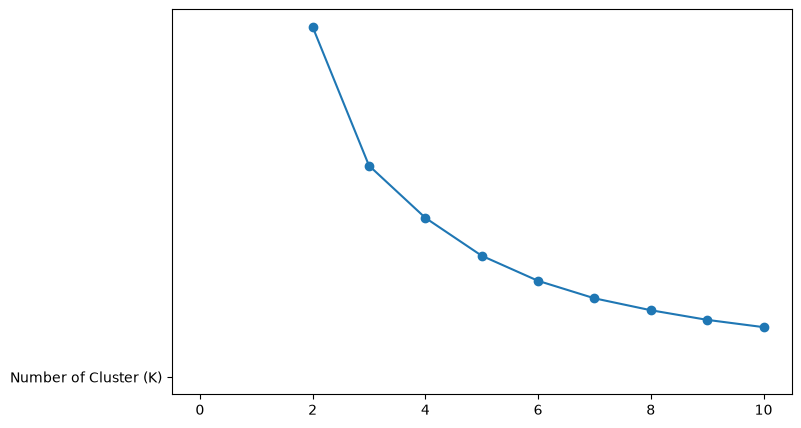

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2,11)

for k in K:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker="o")
plt.plot("Number of Cluster (K)")
plt.show()

In [21]:
kmeans = KMeans(n_clusters = 4, random_state=42,n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [22]:
cluster_profile = rfm.groupby("Cluster").agg(
    Customers = ("CustomerID","count"),
    Avg_Recency = ("Recency","mean"),
    Avg_Frequency = ("Frequency","mean"),
    Avg_Monetary = ("Monetary","mean")
).round(2)

cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,3054,43.70,3.68,1353.63
1,1067,248.08,1.55,478.85
2,13,7.38,82.54,127187.96
3,204,15.50,22.33,12690.50


## Cluster Observations

- Cluster 0: This is the largest customer segment with 3,054 customers. These customers have moderate recency, frequency, and monetary value.
- Cluster 1:This segment has 1,067 customers. These customers have high recency, low purchase frequency, and low monetary value, indicating less recently active customers.
- Cluster 2:This is a small segment with only 13 customers. These customers have very low recency, very high purchase frequency, and very high monetary value, indicating highly valuable and frequent customers.
- Cluster 3: This segment has 204 customers. These customers have low recency, relatively high purchase frequency, and high monetary value, indicating active and valuable customers.

## Marketing Actions

- Cluster 0: Provide personalized recommendations and offers to encourage repeat purchases.
- Cluster 1: Use re-engagement emails, reminders, and special discounts to encourage customers to purchase again.
- Cluster 2: Provide loyalty rewards and personalized offers to retain these high-value customers.
- Cluster 3: Focus on customer retention through loyalty programs and premium offers.

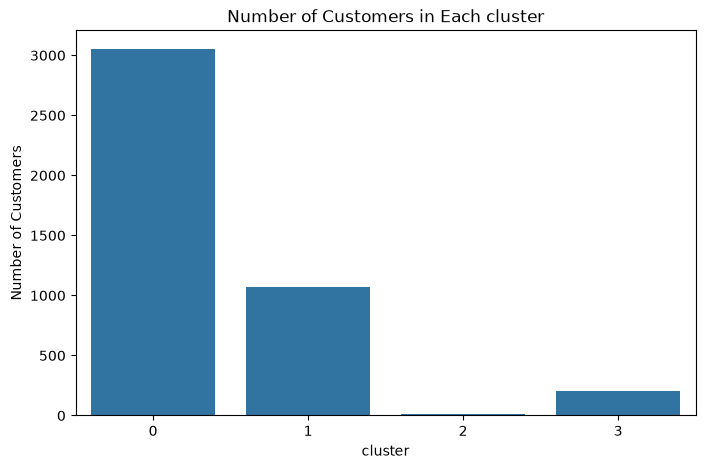

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(data=rfm, x = "Cluster")

plt.title("Number of Customers in Each cluster")
plt.xlabel("cluster")
plt.ylabel("Number of Customers")

plt.show()

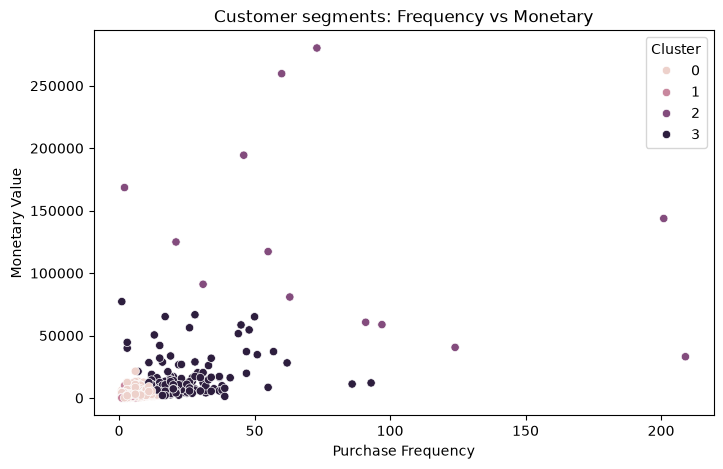

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster"
)

plt.title("Customer segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")

plt.show()

## Scatter Plot Observations

- Cluster 0 contains a large number of customers with relatively low to moderate purchase frequency and monetary value.
- Cluster 1 mainly contains customers with low purchase frequency and low monetary value.
- Cluster 2 contains very few customers, but they have extremely high purchase frequency and monetary value.
- Cluster 3 contains customers with higher purchase frequency and monetary value compared with clusters 0 and 1.

## Key Insights

- Customer segmentation based on RFM analysis identified four distinct customer groups.
- Cluster 0 is the largest segment with 3,054 customers and moderate RFM values.
- Cluster 1 contains 1,067 customers with high recency, low purchase frequency, and low monetary value.
- Cluster 2 contains only 13 customers,but they have extremely high purchase frequency and monetary value.
- Cluster 3 contains 204 customers with low recency,relatively high purchase frequency, and high monetary value.
- Different customer segments can be targeted with different marketing strategies based on their purchasing behaviour.

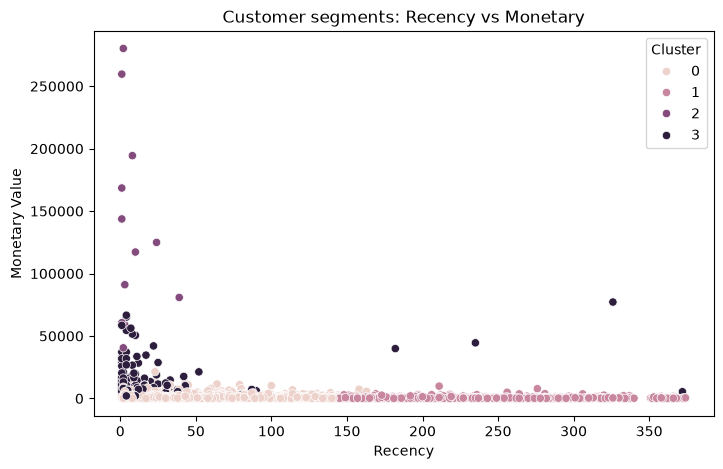

In [26]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster"
)

plt.title("Customer segments: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary Value")

plt.show()

## Second Scatter Plot Observations

- Cluster 0 contains many customers with relatively low to moderate recency and monetary value.
- Cluster 1 mainly contains customers with high recency and low monetary value.
- Cluster 2 contains very few customers with very low recency and extremely high monetary value.
- Cluster 3 contains customers with low recency and high monetary value.


In [29]:
customer_data[[
    "Average_Purchage_Value",
    "Purchase_Frequency",
    "Total_Spend"
]].describe().round(2)

,Average_Purchage_Value,Purchase_Frequency,Total_Spend
count,4338.00,4338.00,4338.00
mean,68.38,4.27,2048.69
std,1467.92,7.70,8985.23
min,2.14,1.00,3.75
25%,12.39,1.00,306.48
50%,17.76,2.00,668.57
75%,24.88,5.00,1660.60
max,77183.60,209.00,280206.02


## Customer Value Note

- Total Spend represents the historical customer value during the observed dataset period.
- It is used as a Customer value proxy for this analysis.
- A true predictive customer Lifetime value would require additional assumptions about future purchases, retention, profit margin, and discounting.